In [16]:
import pandas as pd
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split

In [17]:
df = pd.read_csv('../data/friends_features.csv', index_col='user_id')
df.sample(5)

,friend_id,is_friend,common_friends_count,demographics_sex_user,demographics_age_user,demographics_city_user,education_career_education_university_user,education_career_education_faculty_user,demographics_sex_friend,demographics_age_friend,demographics_city_friend,education_career_education_university_friend,education_career_education_faculty_friend
user_id,,,,,,,,,,,,,
258814756,439146588,True,4,мужской,22.0,Москва,Неизвестно,Неизвестно,мужской,22.0,Москва,РТУ МИРЭА,Институт информационных технологий
163823935,99138057,True,8,мужской,22.0,Подольск,РТУ МИРЭА,Институт информационных технологий,мужской,40.0,Москва,МГУПИ,Институт высоких технологий
227234115,154151541,True,5,мужской,22.0,Москва,МГТУ им. Н. Э. Баумана (бывш. МВТУ),Неизвестно,мужской,22.0,Химки,Неизвестно,Неизвестно
232437875,439146588,True,3,мужской,21.0,Москва,Неизвестно,Неизвестно,мужской,22.0,Москва,РТУ МИРЭА,Институт информационных технологий
248922122,548550935,False,0,мужской,21.0,Москва,Неизвестно,Неизвестно,мужской,20.0,Москва,РТУ МИРЭА,Институт информационных технологий


In [18]:
df['is_friend'].value_counts()

is_friend
True     774
False    438
Name: count, dtype: int64

In [19]:
X = df.drop(columns=['friend_id', 'is_friend'])
y = df['is_friend']

cat_features = ['demographics_sex_user',
                'demographics_city_user',
                'education_career_education_university_user',
                'education_career_education_faculty_user',
                'demographics_sex_friend',
                'demographics_city_friend',
                'education_career_education_university_friend',
                'education_career_education_faculty_friend']

X_train, X_test, y_train, y_test= train_test_split(X, y, train_size=0.8, random_state=42, shuffle=True)

print(X_train.shape)
print(y_train.shape)

print(X_test.shape)
print(y_test.shape)

(969, 11)
(969,)
(243, 11)
(243,)


In [ ]:
model = CatBoostClassifier(iterations=500,
                           learning_rate=0.01,
                           depth=8,
                           loss_function='Logloss',
                           eval_metric='Accuracy',
                           cat_features=cat_features,
                           random_seed=42,
                           task_type='GPU',
                           devices='0',
                           verbose=50)

In [21]:
model.fit(X_train, y_train, eval_set=(X_test, y_test))

0:	learn: 0.8410733	test: 0.7942387	best: 0.7942387 (0)	total: 59.5ms	remaining: 29.7s
50:	learn: 0.8266254	test: 0.7613169	best: 0.8106996 (6)	total: 3.06s	remaining: 26.9s
100:	learn: 0.8503612	test: 0.8148148	best: 0.8148148 (64)	total: 7.55s	remaining: 29.8s
150:	learn: 0.8617131	test: 0.8148148	best: 0.8189300 (121)	total: 12s	remaining: 27.8s
200:	learn: 0.8668731	test: 0.8148148	best: 0.8189300 (121)	total: 16.5s	remaining: 24.6s
250:	learn: 0.8699690	test: 0.8148148	best: 0.8189300 (121)	total: 20.8s	remaining: 20.6s
300:	learn: 0.8730650	test: 0.8189300	best: 0.8189300 (121)	total: 25.2s	remaining: 16.7s
350:	learn: 0.8751290	test: 0.8230453	best: 0.8230453 (309)	total: 30s	remaining: 12.7s
400:	learn: 0.8782250	test: 0.8230453	best: 0.8230453 (309)	total: 34.6s	remaining: 8.55s
450:	learn: 0.8802890	test: 0.8189300	best: 0.8230453 (309)	total: 39.3s	remaining: 4.27s
499:	learn: 0.8823529	test: 0.8189300	best: 0.8230453 (309)	total: 44.1s	remaining: 0us
bestTest = 0.8230452675

In [22]:
print("Accuracy:", model.score(X_test, y_test))

Accuracy: 0.823045267489712


In [32]:
new_data = pd.DataFrame([{
    "common_friends_count": 1,
    "demographics_sex_user": "мужской",
    "demographics_age_user": 22.0,
    "demographics_city_user": "Москва",
    "education_career_education_university_user": "РТУ МИРЭА",
    "education_career_education_faculty_user": "Неизвестно",
    "demographics_sex_friend": "женский",  
    "demographics_age_friend": 25.0,       
    "demographics_city_friend": "Москва",  
    "education_career_education_university_friend": "МГУ",  
    "education_career_education_faculty_friend": "Неизвестно"   
}])

new_data = new_data[X_train.columns]

pred = model.predict(new_data)
print("Predict:", pred)

prob = model.predict_proba(new_data)
print("Friend chance:", prob[0][1])

Predict: [False]
Friend chance: 0.19522327827114233


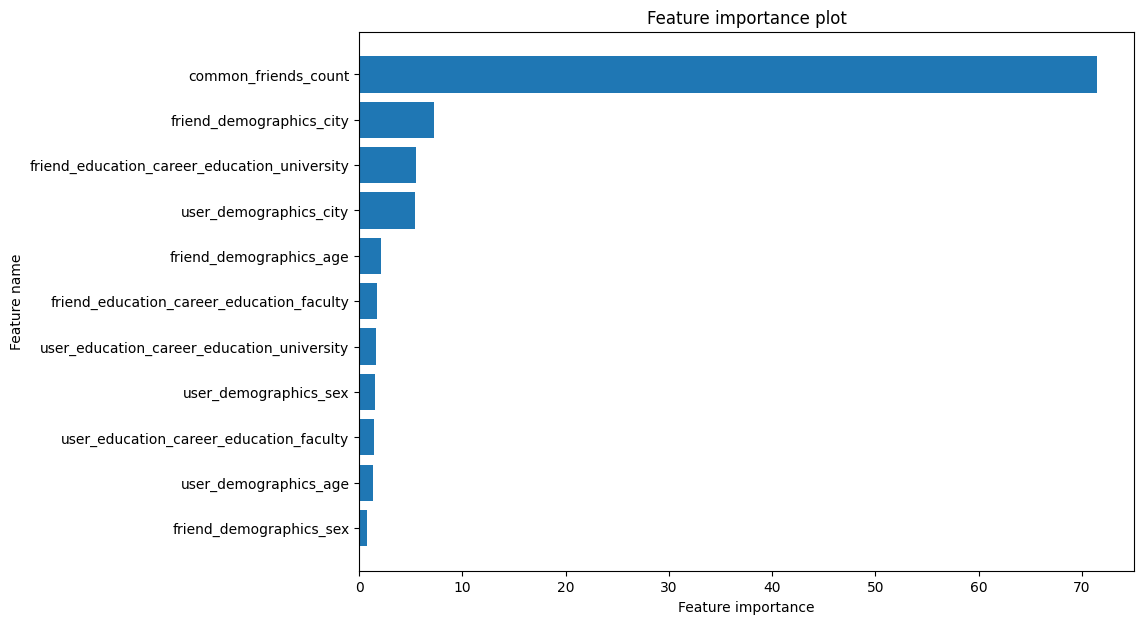

In [ ]:
import matplotlib.pyplot as plt


feature_importance = model.get_feature_importance()
feature_names = X_train.columns

importance_df = pd.DataFrame({'feature_name': feature_names,
                              'feature_importance': feature_importance}).sort_values(by='feature_importance', ascending=True)

plt.figure(figsize=(10,7))
plt.barh(importance_df['feature_name'], importance_df['feature_importance'])
plt.ylabel('Feature name')
plt.xlabel('Feature importance')
plt.title('Feature importance plot')
# plt.xticks(rotation=45, ha='right')
plt.show()